In [4]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [5]:
dsn_file = Path("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/HS_SWE_by_station/HS_SWE_by_station_dsnow_only/Adelboden_dsnow_allseasons.nc")
hs2_file = Path("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/HS_SWE_by_station/HS_SWE_by_station_hs2swe_only/Adelboden_hs2swe_allseasons.nc")

nc_file_hs2swe = "Adelboden_hs2swe_allseasons.nc"
station = nc_file_hs2swe.split("_")[0]



hs2 = xr.open_dataset(hs2_file)
ds  = xr.open_dataset(dsn_file)



measure_source_file = str(station + "_hs_swe_obs.csv")
measure_source_file
path_measure_source_file = str("/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/output/HS_SWE_by_station" + "/" + measure_source_file)

path_measure_source_file

measurments = pd.read_csv(path_measure_source_file)

In [6]:
# Parse observations and map each row to (season, dos)
obs = measurments.copy()
obs["date"] = pd.to_datetime(obs["date"], errors="coerce")
obs = obs.dropna(subset=["date"])

obs["season"] = np.where(obs["date"].dt.month >= 11, obs["date"].dt.year + 1, obs["date"].dt.year).astype(int)
season_start = pd.to_datetime((obs["season"] - 1).astype(str) + "-11-01")
obs["dos"] = ((obs["date"] - season_start).dt.days + 1).astype(int)

# Keep only valid season window and seasons present in the model files
obs = obs[
    obs["season"].isin(hs2["season"].values)
    & obs["dos"].between(1, int(hs2["dos"].max()))
]

# If duplicates exist per day, average them
obs_daily = obs.groupby(["season", "dos"], as_index=False)[["hs", "swe_obs"]].mean()

# Build full (season, dos) grid on hs2 coordinates
idx = pd.MultiIndex.from_product(
    [hs2["season"].values, hs2["dos"].values], names=["season", "dos"]
)
grid = pd.DataFrame(index=idx).join(obs_daily.set_index(["season", "dos"]))

hs_obs_m_hs2 = xr.DataArray(
    grid["hs"].to_numpy().reshape(hs2.sizes["season"], hs2.sizes["dos"]),
    coords={"season": hs2["season"].values, "dos": hs2["dos"].values},
    dims=("season", "dos"),
    name="HS_obs_m",
)
swe_obs_mm_hs2 = xr.DataArray(
    grid["swe_obs"].to_numpy().reshape(hs2.sizes["season"], hs2.sizes["dos"]),
    coords={"season": hs2["season"].values, "dos": hs2["dos"].values},
    dims=("season", "dos"),
    name="SWE_obs_mm",
)

# Add/overwrite observation variables in hs2
hs2["HS_obs_cm"] = hs_obs_m_hs2 * 100.0
hs2["HS_obs_cm"].attrs["units"] = "cm"
hs2["SWE_obs_mm"] = swe_obs_mm_hs2
hs2["SWE_obs_mm"].attrs["units"] = "mm"

# Add/overwrite observation variables in ds (reindexed to ds dos length, then match (dos, season) layout)
ds["HS_meas_m"] = hs_obs_m_hs2.reindex(season=ds["season"], dos=ds["dos"]).transpose("dos", "season")
ds["HS_meas_m"].attrs["units"] = "m"
ds["SWE_obs_mm"] = swe_obs_mm_hs2.reindex(season=ds["season"], dos=ds["dos"]).transpose("dos", "season")
ds["SWE_obs_mm"].attrs["units"] = "mm"

# Save to new NetCDF files
dsn_out = dsn_file.with_name(f"{dsn_file.stem}_with_obs.nc")
hs2_out = hs2_file.with_name(f"{hs2_file.stem}_with_obs.nc")
ds.to_netcdf(dsn_out)
hs2.to_netcdf(hs2_out)

print("Wrote:", dsn_out)
print("Wrote:", hs2_out)

Wrote: /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/HS_SWE_by_station/HS_SWE_by_station_dsnow_only/Adelboden_dsnow_allseasons_with_obs.nc
Wrote: /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/HS_SWE_by_station/HS_SWE_by_station_hs2swe_only/Adelboden_hs2swe_allseasons_with_obs.nc


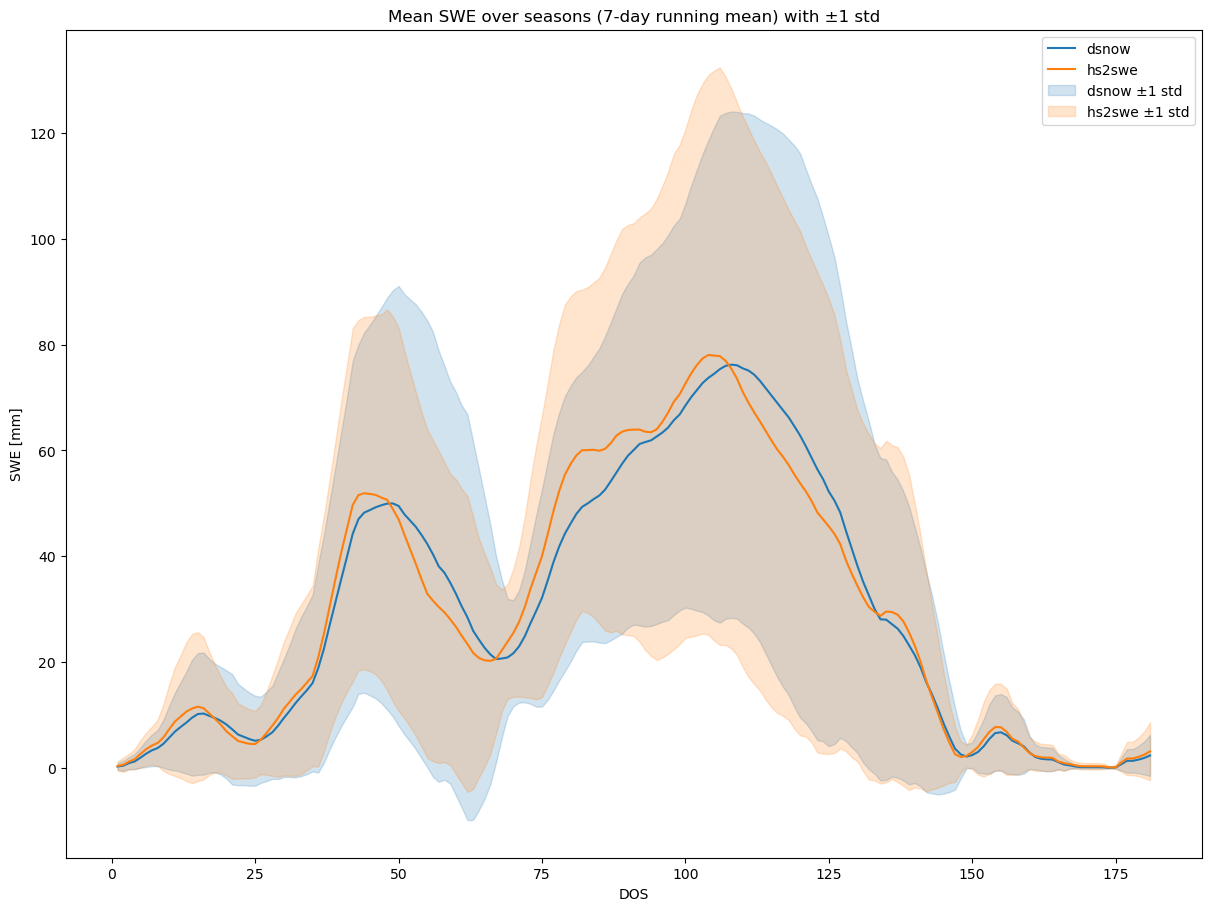

In [7]:
# SWE comparison (assumed same unit: mm)
swe_ds = ds["SWE_total"].transpose("season", "dos")
swe_hs2 = hs2["SWE_mm"].transpose("season", "dos")
swe_ds, swe_hs2 = xr.align(swe_ds, swe_hs2, join="inner")

# Total HS comparison (hs2 is cm -> convert to m)
hs_ds = ds["HS"].sum("layer").transpose("season", "dos")
hs_hs2 = (hs2["HS_layer_cm"].sum("layer") / 100.0).transpose("season", "dos")
hs_ds, hs_hs2 = xr.align(hs_ds, hs_hs2, join="inner")

# 7-day running mean
window = 7
swe_ds_7d = swe_ds.rolling(dos=window, center=True, min_periods=1).mean()
swe_hs2_7d = swe_hs2.rolling(dos=window, center=True, min_periods=1).mean()
hs_ds_7d = hs_ds.rolling(dos=window, center=True, min_periods=1).mean()
hs_hs2_7d = hs_hs2.rolling(dos=window, center=True, min_periods=1).mean()

# Mean and std across seasons
swe_ds_mean = swe_ds_7d.mean("season", skipna=True)
swe_ds_std = swe_ds_7d.std("season", skipna=True)
swe_hs2_mean = swe_hs2_7d.mean("season", skipna=True)
swe_hs2_std = swe_hs2_7d.std("season", skipna=True)

fig, axes = plt.subplots(1, 1, figsize=(12, 9), constrained_layout=True)

dos = swe_ds_7d["dos"].values

# Mean lines
axes.plot(dos, swe_ds_mean.values, label="dsnow", color="C0")
axes.plot(dos, swe_hs2_mean.values, label="hs2swe", color="C1")

# ±1 std shading
axes.fill_between(
    dos,
    (swe_ds_mean - swe_ds_std).values,
    (swe_ds_mean + swe_ds_std).values,
    color="C0",
    alpha=0.2,
    label="dsnow ±1 std",
)
axes.fill_between(
    dos,
    (swe_hs2_mean - swe_hs2_std).values,
    (swe_hs2_mean + swe_hs2_std).values,
    color="C1",
    alpha=0.2,
    label="hs2swe ±1 std",
)

axes.set_title("Mean SWE over seasons (7-day running mean) with ±1 std")
axes.set_xlabel("DOS")
axes.set_ylabel("SWE [mm]")
axes.legend()

plt.show()

In [8]:
# seasons = swe_ds["season"].values

# # Observations from ds on the same DOS grid as model daily series
# hs_obs = ds["HS_meas_m"].transpose("season", "dos").sel(dos=hs_ds["dos"])
# swe_obs = ds["SWE_obs_mm"].transpose("season", "dos").sel(dos=swe_ds["dos"])

# n = len(seasons)
# fig, axes = plt.subplots(n, 2, figsize=(14, 2.8 * n), sharex=True, constrained_layout=True)
# if n == 1:
#     axes = np.array([axes])

# for i, season in enumerate(seasons):
#     # SWE (daily)
#     ax_swe = axes[i, 0]
#     ax_swe.plot(swe_ds["dos"], swe_ds.sel(season=season), lw=1.8, label="dsnow (daily)")
#     ax_swe.plot(swe_hs2["dos"], swe_hs2.sel(season=season), lw=1.8, label="hs2swe (daily)")
#     swe_obs_season = swe_obs.sel(season=season)
#     m_swe = np.isfinite(swe_obs_season.values)
#     ax_swe.scatter(
#         swe_obs_season["dos"].values[m_swe],
#         swe_obs_season.values[m_swe],
#         s=18,
#         c="k",
#         label="obs",
#         zorder=3,
#     )
#     ax_swe.set_ylabel(f"SWE [mm]\n{int(season)}")
#     if i == 0:
#         ax_swe.set_title("SWE by season")
#         ax_swe.legend()

#     # HS (daily)
#     ax_hs = axes[i, 1]
#     ax_hs.plot(hs_ds["dos"], hs_ds.sel(season=season), lw=1.8, label="dsnow (daily)")
#     ax_hs.plot(hs_hs2["dos"], hs_hs2.sel(season=season), lw=1.8, label="hs2swe (daily)")
#     hs_obs_season = hs_obs.sel(season=season)
#     m_hs = np.isfinite(hs_obs_season.values)
#     ax_hs.scatter(
#         hs_obs_season["dos"].values[m_hs],
#         hs_obs_season.values[m_hs],
#         s=12,
#         c="k",
#         label="obs",
#         zorder=3,
#     )
#     ax_hs.set_ylabel("HS [m]")
#     if i == 0:
#         ax_hs.set_title("HS by season")
#         ax_hs.legend()

# axes[-1, 0].set_xlabel("DOS")
# axes[-1, 1].set_xlabel("DOS")
# plt.show()

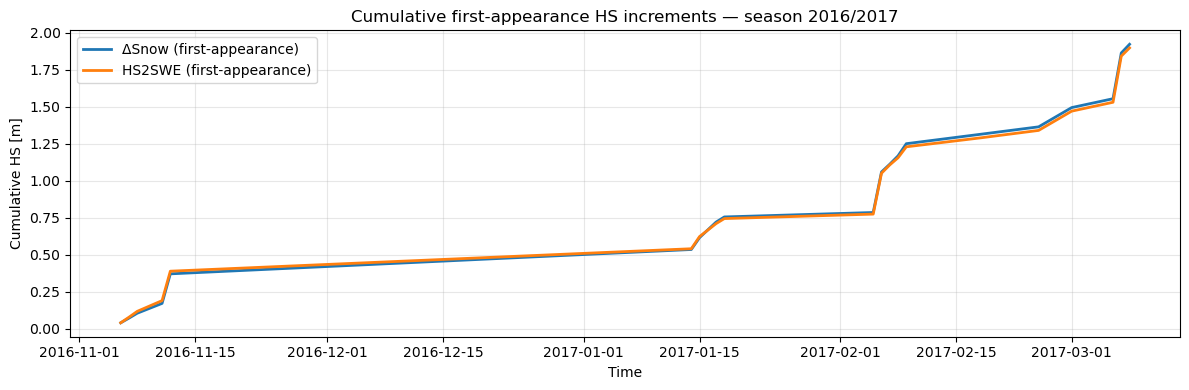

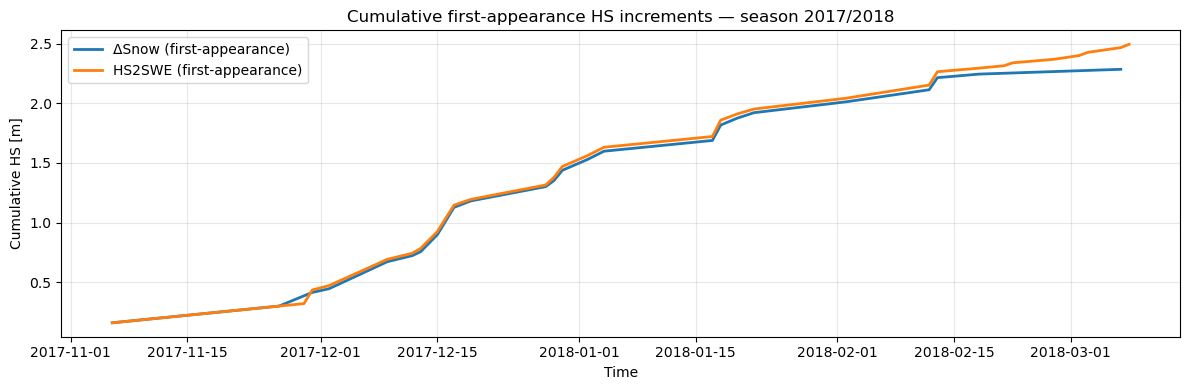

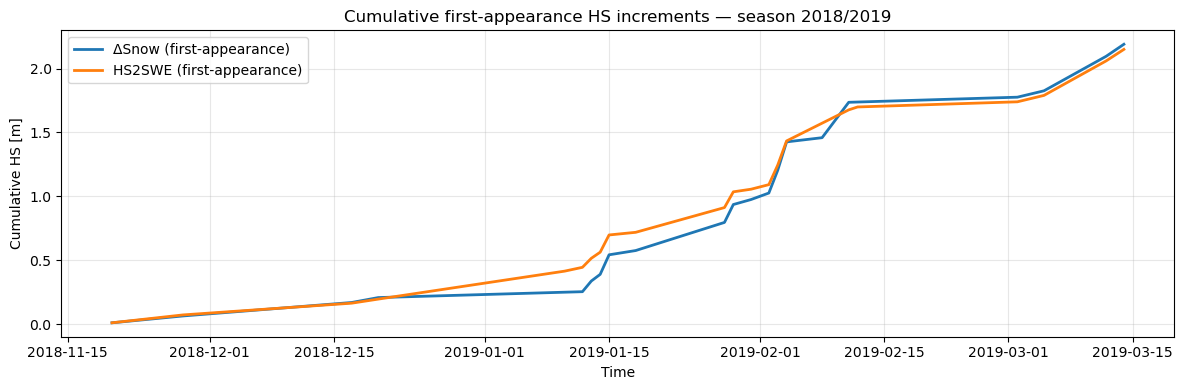

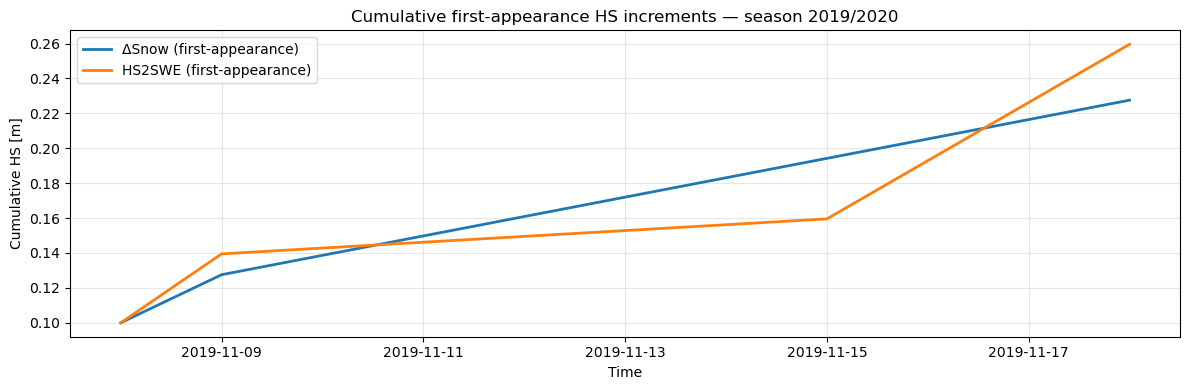

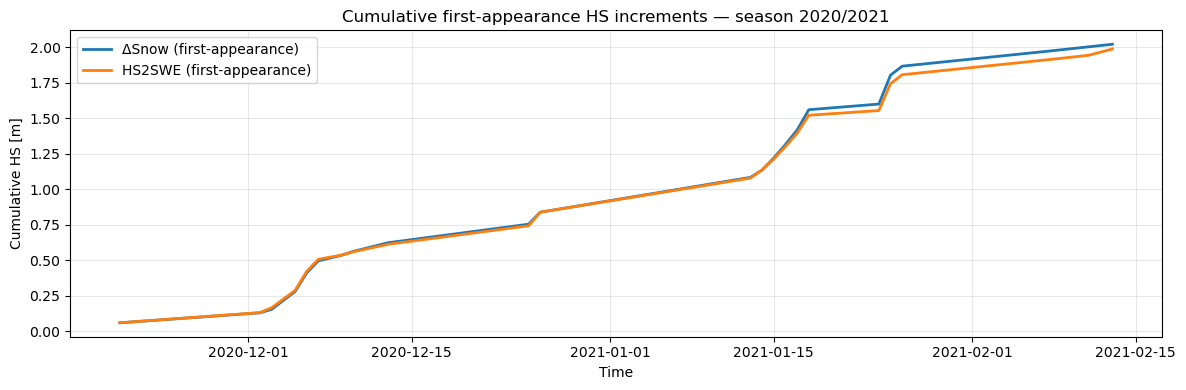

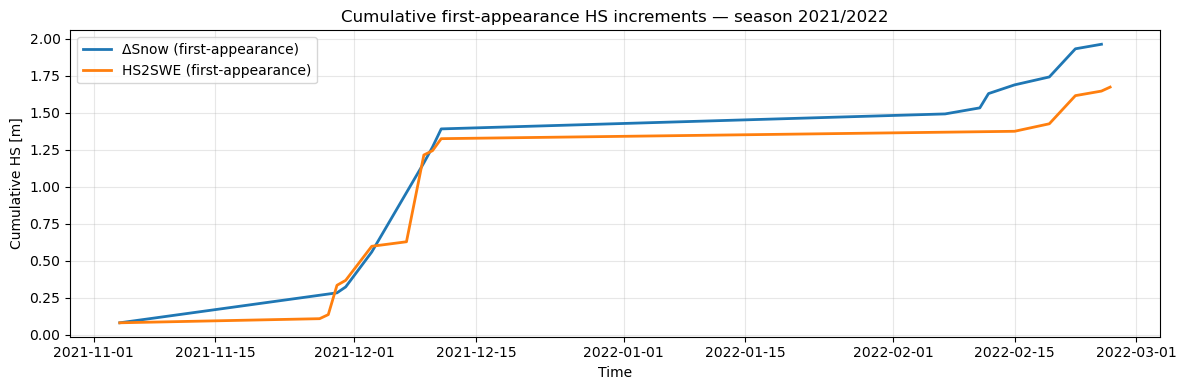

In [9]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


def _first_appearance_events(layer_da: xr.DataArray, scale_to_m: float = 1.0) -> pd.DataFrame:
    # Ensure order (season, dos, layer)
    da = (layer_da * scale_to_m).transpose("season", "dos", "layer")

    pos = (da > 0) & np.isfinite(da)          # (season,dos,layer)
    has_pos = pos.any("dos")                  # (season,layer)
    first_idx = pos.argmax("dos")             # (season,layer), 0-based index in dos

    first_dos = da["dos"].isel(dos=first_idx).where(has_pos).rename("first_dos")
    first_inc = da.isel(dos=first_idx).where(has_pos).rename("inc").reset_coords(drop=True)

    ev = xr.Dataset({"first_dos": first_dos, "inc": first_inc}).to_dataframe().reset_index()
    ev = ev.dropna(subset=["first_dos", "inc"]).copy()

    ev["season"] = ev["season"].astype(int)
    ev["first_dos"] = ev["first_dos"].astype(int)
    ev["timestamp"] = (
        pd.to_datetime((ev["season"] - 1).astype(str) + "-11-01")
        + pd.to_timedelta(ev["first_dos"] - 1, unit="D")
    )
    return ev[["season", "timestamp", "inc"]]


def _season_curve(events: pd.DataFrame, season: int) -> pd.DataFrame:
    out = (
        events.loc[events["season"] == season]
        .groupby("timestamp", as_index=True)["inc"]
        .sum()
        .sort_index()
        .to_frame("increment")
    )
    out["cumulative"] = out["increment"].cumsum()
    return out


# Inputs
hs_ds_layers = ds["HS"]                 # [m]
hs_hs2_layers = hs2["HS_layer_cm"]      # [cm]

# First-appearance events
ev_ds = _first_appearance_events(hs_ds_layers, scale_to_m=1.0)
ev_hs2 = _first_appearance_events(hs_hs2_layers, scale_to_m=0.01)

# Common seasons in both datasets
season_vals = np.intersect1d(ds["season"].values, hs2["season"].values).astype(int)

# Plot each season separately
for s in season_vals:
    hs_df = _season_curve(ev_ds, s)
    hs2_df = _season_curve(ev_hs2, s)

    fig, ax = plt.subplots(figsize=(12, 4))
    if not hs_df.empty:
        ax.plot(hs_df.index, hs_df["cumulative"], lw=2, label="ΔSnow (first-appearance)")
    if not hs2_df.empty:
        ax.plot(hs2_df.index, hs2_df["cumulative"], lw=2, label="HS2SWE (first-appearance)")

    ax.set_title(f"Cumulative first-appearance HS increments — season {s-1}/{s}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Cumulative HS [m]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


,n,mean,median,q25,q75,iqr,std
delta-snow,6.0,1.7681,1.9925,1.9313,2.1482,0.2169,0.7674
hs2swe,6.0,1.7438,1.9424,1.7293,2.1098,0.3805,0.7772


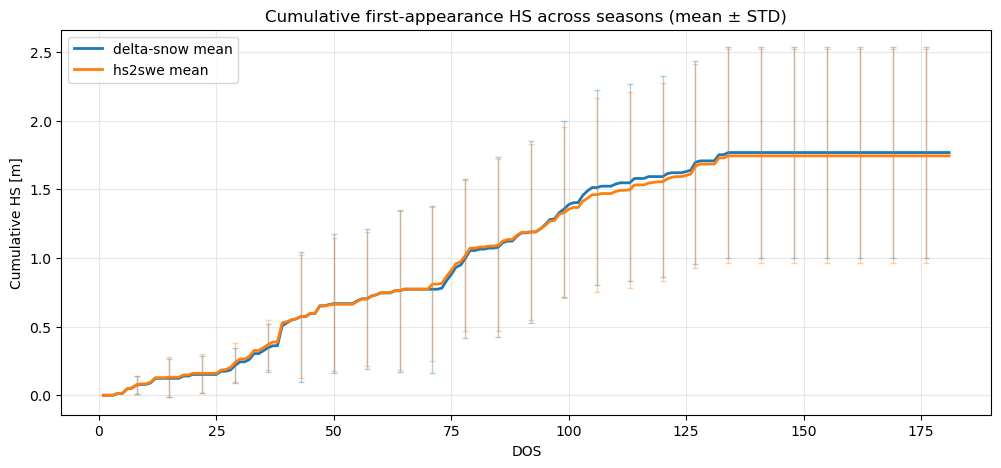

In [10]:
# Config: choose curve center and error bars
center_stat = "mean"   # "mean" or "median"
error_stat = "std"     # "std" or "iqr"
errorevery = 7         # show error bars every N DOS points

# Reuse first-appearance events if already available
if "ev_ds" not in globals():
    ev_ds = _first_appearance_events(hs_ds_layers, scale_to_m=1.0)
if "ev_hs2" not in globals():
    ev_hs2 = _first_appearance_events(hs_hs2_layers, scale_to_m=0.01)

season_vals = np.intersect1d(ds["season"].values, hs2["season"].values).astype(int)
dos_vals = np.intersect1d(ds["dos"].values, hs2["dos"].values).astype(int)

def _cumulative_matrix_from_events(events: pd.DataFrame, seasons: np.ndarray, dos: np.ndarray) -> pd.DataFrame:
    e = events.copy()
    e["season_start"] = pd.to_datetime((e["season"] - 1).astype(str) + "-11-01")
    e["dos"] = ((e["timestamp"] - e["season_start"]).dt.days + 1).astype(int)

    daily = e.groupby(["season", "dos"], as_index=False)["inc"].sum()

    idx = pd.MultiIndex.from_product([seasons, dos], names=["season", "dos"])
    inc = (
        daily.set_index(["season", "dos"])["inc"]
        .reindex(idx, fill_value=0.0)
        .unstack("season")
    )
    return inc.cumsum(axis=0)

def _curve_stats(cum_mat: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=cum_mat.index)
    out["mean"] = cum_mat.mean(axis=1)
    out["median"] = cum_mat.median(axis=1)
    out["std"] = cum_mat.std(axis=1, ddof=1)
    out["q25"] = cum_mat.quantile(0.25, axis=1)
    out["q75"] = cum_mat.quantile(0.75, axis=1)
    out["iqr"] = out["q75"] - out["q25"]
    return out

def _final_summary(cum_mat: pd.DataFrame) -> pd.Series:
    vals = cum_mat.iloc[-1].to_numpy(dtype=float)  # end-of-season totals
    q25 = np.quantile(vals, 0.25)
    q75 = np.quantile(vals, 0.75)
    return pd.Series(
        {
            "n": len(vals),
            "mean": np.mean(vals),
            "median": np.median(vals),
            "q25": q25,
            "q75": q75,
            "iqr": q75 - q25,
            "std": np.std(vals, ddof=1),
        }
    )

cum_ds = _cumulative_matrix_from_events(ev_ds, season_vals, dos_vals)
cum_hs2 = _cumulative_matrix_from_events(ev_hs2, season_vals, dos_vals)

stats_ds = _curve_stats(cum_ds)
stats_hs2 = _curve_stats(cum_hs2)

summary = pd.DataFrame(
    {
        "delta-snow": _final_summary(cum_ds),
        "hs2swe": _final_summary(cum_hs2),
    }
).T
display(summary.round(4))

fig, ax = plt.subplots(figsize=(12, 5))

for stats, color, label in [
    (stats_ds, "C0", "delta-snow"),
    (stats_hs2, "C1", "hs2swe"),
]:
    center = stats[center_stat]

    if error_stat == "std":
        yerr = stats["std"].to_numpy()
    else:  # iqr (asymmetric around center)
        yerr = np.vstack([
            (center - stats["q25"]).to_numpy(),
            (stats["q75"] - center).to_numpy(),
        ])

    ax.plot(dos_vals, center.to_numpy(), color=color, lw=2, label=f"{label} {center_stat}")
    ax.errorbar(
        dos_vals,
        center.to_numpy(),
        yerr=yerr,
        fmt="none",
        ecolor=color,
        alpha=0.35,
        elinewidth=1,
        capsize=2,
        errorevery=errorevery,
    )

ax.set_title(f"Cumulative first-appearance HS across seasons ({center_stat} ± {error_stat.upper()})")
ax.set_xlabel("DOS")
ax.set_ylabel("Cumulative HS [m]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [11]:
# SWE RMSE + relative bias + scatter plots (separate panels for delta-snow and hs2swe)

# Align on common coordinates
swe_obs_al, swe_ds_al, swe_hs2_al = xr.align(swe_obs, swe_ds, swe_hs2, join="inner")

obs_flat = swe_obs_al.values.ravel()
ds_flat = swe_ds_al.values.ravel()
hs2_flat = swe_hs2_al.values.ravel()

def _metrics(obs_arr, mod_arr):
    mask = np.isfinite(obs_arr) & np.isfinite(mod_arr)
    o = obs_arr[mask]
    m = mod_arr[mask]
    n = mask.sum()
    if n == 0:
        return mask, np.nan, np.nan, 0

    rmse = np.sqrt(np.mean((m - o) ** 2))
    # Relative bias as percent bias: 100 * sum(model - obs) / sum(obs)
    denom = np.sum(o)
    rel_bias = np.nan if np.isclose(denom, 0.0) else 100.0 * np.sum(m - o) / denom
    return mask, rmse, rel_bias, n

mask_ds, rmse_ds, rel_bias_ds, n_ds = _metrics(obs_flat, ds_flat)
mask_hs2, rmse_hs2, rel_bias_hs2, n_hs2 = _metrics(obs_flat, hs2_flat)

print(f"delta-snow: RMSE={rmse_ds:.2f} mm, RelBias={rel_bias_ds:+.2f}% (n={n_ds})")
print(f"hs2swe    : RMSE={rmse_hs2:.2f} mm, RelBias={rel_bias_hs2:+.2f}% (n={n_hs2})")

all_vals = np.concatenate([
    obs_flat[mask_ds], ds_flat[mask_ds],
    obs_flat[mask_hs2], hs2_flat[mask_hs2]
])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True, constrained_layout=True)

panels = [
    ("delta-snow", ds_flat, mask_ds, rmse_ds, rel_bias_ds, n_ds),
    ("hs2swe", hs2_flat, mask_hs2, rmse_hs2, rel_bias_hs2, n_hs2),
]

for ax, (name, mod_flat, mask, rmse, rb, n) in zip(axes, panels):
    ax.scatter(obs_flat[mask], mod_flat[mask], s=35, alpha=0.75)
    ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1)
    ax.set_title(f"{name}: Observed vs modelled SWE")
    ax.set_xlabel("Observed SWE [mm]")
    ax.set_ylabel("Modelled SWE [mm]")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_aspect("equal", adjustable="box")

    ax.text(
        0.03, 0.97,
        f"RMSE = {rmse:.2f} mm\nRel. bias = {rb:+.2f}%\nn = {n}",
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

plt.show()

NameError: name 'swe_obs' is not defined

In [13]:
# Load all NetCDF files from:
# model_diff/R_comparisson/output/HS_SWE_by_station/allseason_all_station/netcdf_with_obs
# (derived from existing `summary_file`)
nc_dir = Path(summary_file).parent / "netcdf_with_obs"
nc_files = sorted(nc_dir.glob("*.nc"))

if not nc_files:
    raise FileNotFoundError(f"No .nc files found in: {nc_dir}")

# Dictionary keyed by file stem (filename without .nc)
all_nc = {f.stem: xr.open_dataset(f) for f in nc_files}

print(f"Loaded {len(all_nc)} NetCDF files from:\n{nc_dir}")
print("Keys:", list(all_nc.keys()))

Loaded 108 NetCDF files from:
/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/HS_SWE_by_station/allseason_all_station/netcdf_with_obs
Keys: ['Adelboden_dsnow_allseasons_with_obs', 'Adelboden_hs2swe_allseasons_with_obs', 'Binn_dsnow_allseasons_with_obs', 'Binn_hs2swe_allseasons_with_obs', 'Bivio_dsnow_allseasons_with_obs', 'Bivio_hs2swe_allseasons_with_obs', 'Bosco_Gurin_dsnow_allseasons_with_obs', 'Bosco_Gurin_hs2swe_allseasons_with_obs', 'Bourg_St_Pierre_dsnow_allseasons_with_obs', 'Bourg_St_Pierre_hs2swe_allseasons_with_obs', 'Braunwald_dsnow_allseasons_with_obs', 'Braunwald_hs2swe_allseasons_with_obs', 'Davos_Flueelastr_dsnow_allseasons_with_obs', 'Davos_Flueelastr_dsnow_dsnow_allseasons_with_obs', 'Davos_Flueelastr_dsnow_hs2swe_allseasons_with_obs', 'Davos_Flueelastr_hs2swe_allseasons_with_obs', 'Felbertauern_dsnow_allseasons_with_obs', 'Felbertauern_hs2swe_allseasons_with_obs', 'Fionnay_dsnow_allseasons_with_obs', 'Fionnay_hs2swe_allseasons_with_obs', 'Gadmen_

dsnow stats (first rows):
   dos      mean        std  median  q25       q75    n       iqr
0    1  0.000000   0.000000     0.0  0.0  0.000000  390  0.000000
1    2  1.725064   5.982513     0.0  0.0  0.000000  390  0.000000
2    3  2.066485   7.100638     0.0  0.0  0.000000  390  0.000000
3    4  3.998582   9.967562     0.0  0.0  0.000000  390  0.000000
4    5  4.547657  10.478031     0.0  0.0  1.623883  390  1.623883

hs2swe stats (first rows):
   dos      mean        std  median  q25    q75    n    iqr
0    1  0.000000   0.000000     0.0  0.0  0.000  390  0.000
1    2  2.415688   8.377594     0.0  0.0  0.000  390  0.000
2    3  2.866425   9.528126     0.0  0.0  0.000  390  0.000
3    4  5.427596  13.381226     0.0  0.0  0.000  390  0.000
4    5  6.080850  13.796625     0.0  0.0  2.274  390  2.274


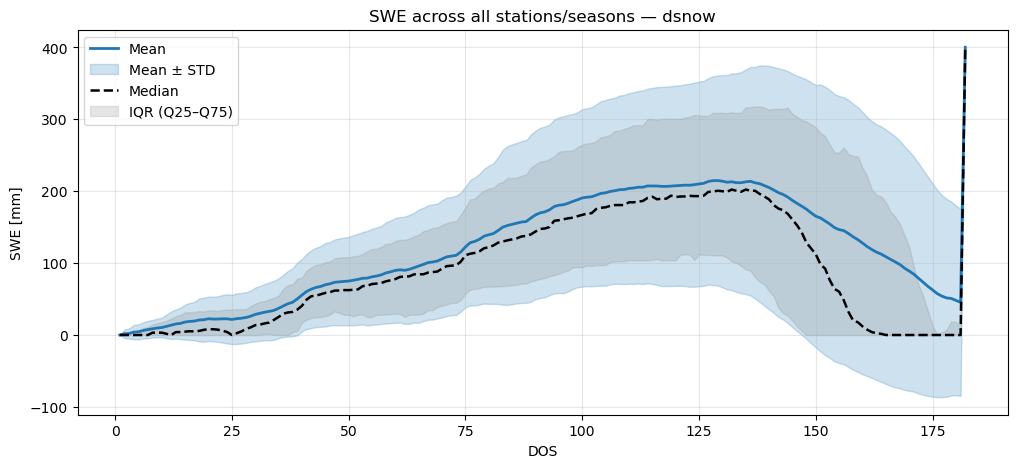

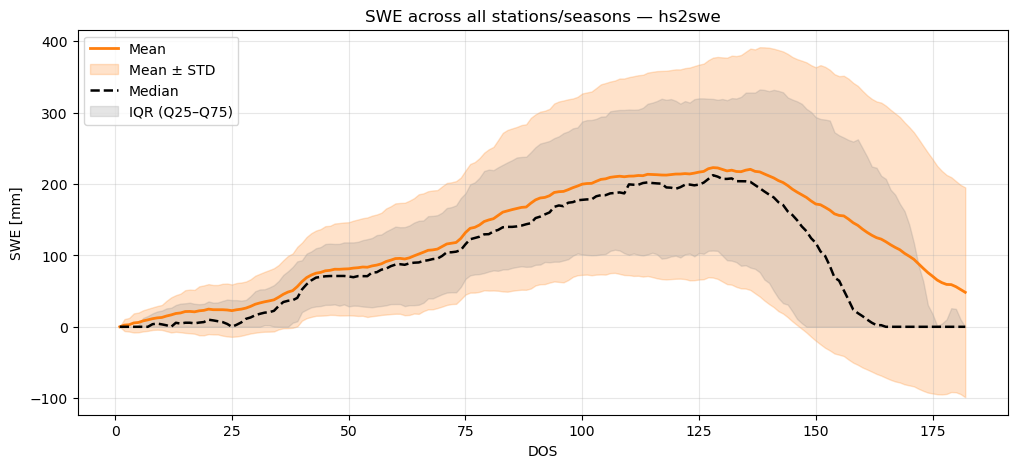

In [14]:
# Build long SWE table across all loaded station NetCDFs
if "all_nc" not in globals():
    nc_dir = Path(summary_file).parent / "netcdf_with_obs"
    nc_files = sorted(nc_dir.glob("*.nc"))
    all_nc = {f.stem: xr.open_dataset(f) for f in nc_files}

def _detect_model_and_var(key: str, dsx: xr.Dataset):
    k = key.lower()

    # Prefer filename hint
    if "hs2swe" in k:
        if "SWE_mm" in dsx:
            return "hs2swe", "SWE_mm"
        if "SWE_total" in dsx:
            return "hs2swe", "SWE_total"

    if "dsnow" in k or "dsn" in k:
        if "SWE_total" in dsx:
            return "dsnow", "SWE_total"
        if "SWE_mm" in dsx:
            return "dsnow", "SWE_mm"

    # Fallback by variable presence
    if "SWE_total" in dsx and "SWE_mm" not in dsx:
        return "dsnow", "SWE_total"
    if "SWE_mm" in dsx:
        return "hs2swe", "SWE_mm"
    if "SWE_total" in dsx:
        return "dsnow", "SWE_total"

    return None, None

rows = []
for key, dsx in all_nc.items():
    model, var = _detect_model_and_var(key, dsx)
    if model is None:
        continue

    da = dsx[var].squeeze(drop=True)
    if "dos" not in da.dims:
        continue

    # Reduce unexpected extra dims, keep only season/dos
    extra_dims = [d for d in da.dims if d not in ("season", "dos")]
    if extra_dims:
        da = da.mean(extra_dims, skipna=True)

    if "season" not in da.dims:
        da = da.expand_dims(season=[-1])

    da = da.transpose("season", "dos")
    tmp = da.to_dataframe(name="swe").reset_index()
    tmp["model"] = model
    tmp["station"] = key.split("_")[0]
    rows.append(tmp[["model", "station", "season", "dos", "swe"]])

if not rows:
    raise ValueError("No SWE data found in loaded NetCDF files.")

all_swe = pd.concat(rows, ignore_index=True)
all_swe = all_swe[np.isfinite(all_swe["swe"])].copy()

def _dos_stats(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("dos")["swe"]
    out = pd.DataFrame({
        "mean": g.mean(),
        "std": g.std(ddof=1).fillna(0.0),
        "median": g.median(),
        "q25": g.quantile(0.25),
        "q75": g.quantile(0.75),
        "n": g.count(),
    }).sort_index()
    out["iqr"] = out["q75"] - out["q25"]
    return out.reset_index()

dsnow_stats = _dos_stats(all_swe[all_swe["model"] == "dsnow"])
hs2swe_stats = _dos_stats(all_swe[all_swe["model"] == "hs2swe"])

print("dsnow stats (first rows):")
print(dsnow_stats.head())
print("\nhs2swe stats (first rows):")
print(hs2swe_stats.head())

def _plot_swe_stats(stats: pd.DataFrame, title: str, color: str):
    fig, ax = plt.subplots(figsize=(12, 5))
    x = stats["dos"].to_numpy()

    mean = stats["mean"].to_numpy()
    std = stats["std"].to_numpy()
    median = stats["median"].to_numpy()
    q25 = stats["q25"].to_numpy()
    q75 = stats["q75"].to_numpy()

    ax.plot(x, mean, color=color, lw=2, label="Mean")
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.22, label="Mean ± STD")

    ax.plot(x, median, color="k", lw=1.8, ls="--", label="Median")
    ax.fill_between(x, q25, q75, color="gray", alpha=0.20, label="IQR (Q25–Q75)")

    ax.set_title(title)
    ax.set_xlabel("DOS")
    ax.set_ylabel("SWE [mm]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

# Plot 1: dsnow
_plot_swe_stats(dsnow_stats, "SWE across all stations/seasons — dsnow", "C0")

# Plot 2: hs2swe
_plot_swe_stats(hs2swe_stats, "SWE across all stations/seasons — hs2swe", "C1")

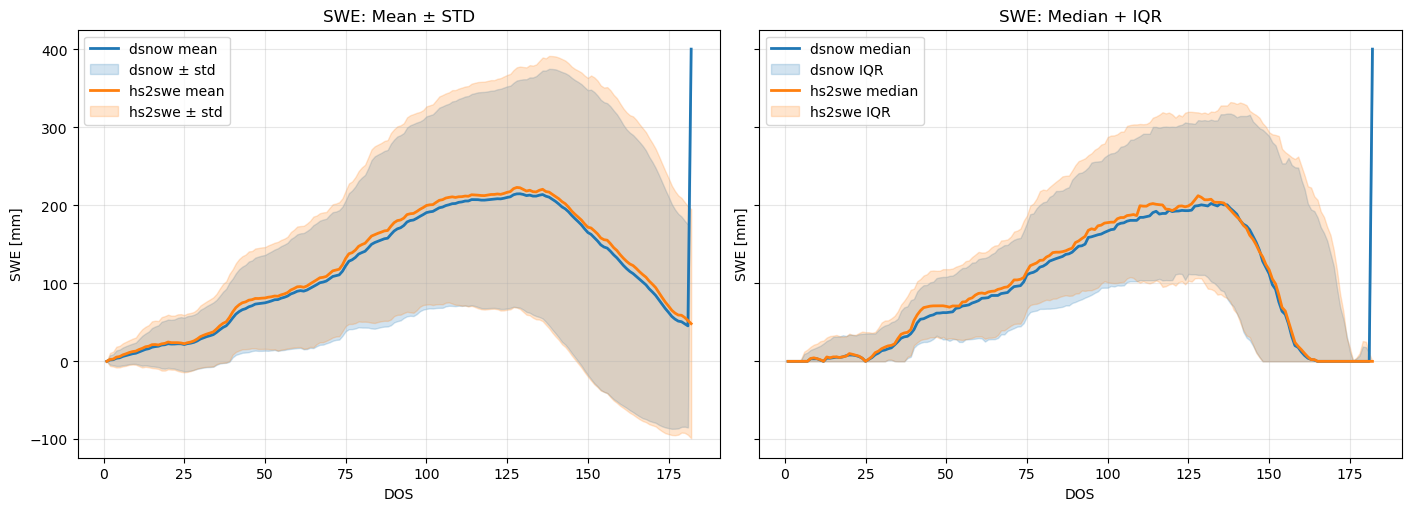

In [15]:
# Compare dsnow vs hs2swe in one figure:
# left = mean ± std, right = median + IQR

if "dsnow_stats" not in globals() or "hs2swe_stats" not in globals():
    dsnow_stats = _dos_stats(all_swe[all_swe["model"] == "dsnow"])
    hs2swe_stats = _dos_stats(all_swe[all_swe["model"] == "hs2swe"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True, constrained_layout=True)

for stats, color, label in [
    (dsnow_stats, "C0", "dsnow"),
    (hs2swe_stats, "C1", "hs2swe"),
]:
    x = stats["dos"].to_numpy()

    # Panel 1: Mean ± STD
    mean = stats["mean"].to_numpy()
    std = stats["std"].to_numpy()
    axes[0].plot(x, mean, color=color, lw=2, label=f"{label} mean")
    axes[0].fill_between(x, mean - std, mean + std, color=color, alpha=0.2, label=f"{label} ± std")

    # Panel 2: Median + IQR
    med = stats["median"].to_numpy()
    q25 = stats["q25"].to_numpy()
    q75 = stats["q75"].to_numpy()
    axes[1].plot(x, med, color=color, lw=2, label=f"{label} median")
    axes[1].fill_between(x, q25, q75, color=color, alpha=0.2, label=f"{label} IQR")

axes[0].set_title("SWE: Mean ± STD")
axes[1].set_title("SWE: Median + IQR")

for ax in axes:
    ax.set_xlabel("DOS")
    ax.set_ylabel("SWE [mm]")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.show()

End-of-season cumulative HS [m] across all stations + seasons:
        n    mean  std  median     q25     q75  iqr
model                                              
hs2swe  1  6.8257  NaN  6.8257  6.8257  6.8257  0.0


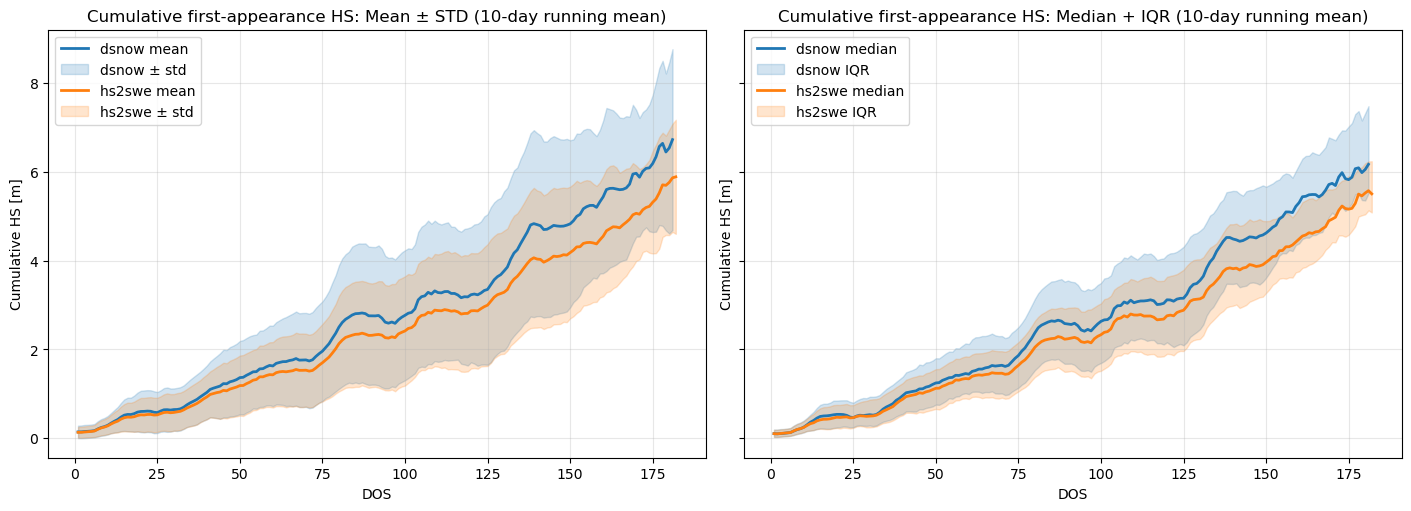

In [19]:
# Across all stations + seasons: cumulative first-appearance HS stats
# with mean±std and median+IQR for dsnow vs hs2swe

RUNNING_MEAN_DAYS = 10 # set to 1 (no smoothing), or 3, 5, 7, ...

if RUNNING_MEAN_DAYS < 1:
    raise ValueError("RUNNING_MEAN_DAYS must be >= 1")

if "_first_appearance_events" not in globals():
    raise RuntimeError("Run the cell that defines _first_appearance_events first.")

if "all_nc" not in globals():
    nc_dir = Path(summary_file).parent / "netcdf_with_obs"
    nc_files = sorted(nc_dir.glob("*.nc"))
    if not nc_files:
        raise FileNotFoundError(f"No .nc files found in: {nc_dir}")
    all_nc = {f.stem: xr.open_dataset(f) for f in nc_files}


def _detect_hs_model_var_scale(key: str, dsx: xr.Dataset):
    k = key.lower()
    if "hs2swe" in k and "HS_layer_cm" in dsx:
        return "hs2swe", "HS_layer_cm", 0.01
    if ("dsnow" in k or "dsn" in k) and "HS" in dsx and "layer" in dsx["HS"].dims:
        return "dsnow", "HS", 1.0
    if "HS_layer_cm" in dsx:
        return "hs2swe", "HS_layer_cm", 0.01
    if "HS" in dsx and "layer" in dsx["HS"].dims:
        return "dsnow", "HS", 1.0
    return None, None, None


events_rows = []
dos_sets = {"dsnow": set(), "hs2swe": set()}

for key, dsx in all_nc.items():
    model, var_hs, scale = _detect_hs_model_var_scale(key, dsx)
    if model is None:
        continue

    da = dsx[var_hs].squeeze(drop=True)

    extra_dims = [d for d in da.dims if d not in ("season", "dos", "layer")]
    if extra_dims:
        da = da.mean(extra_dims, skipna=True)

    if not all(d in da.dims for d in ("season", "dos", "layer")):
        continue

    dos_sets[model].update(np.asarray(da["dos"].values, dtype=int).tolist())

    ev = _first_appearance_events(da, scale_to_m=scale)
    if ev.empty:
        continue

    ev["station"] = key.split("_")[0]
    ev["model"] = model
    ev["season_start"] = pd.to_datetime((ev["season"] - 1).astype(str) + "-11-01")
    ev["dos"] = ((ev["timestamp"] - ev["season_start"]).dt.days + 1).astype(int)
    events_rows.append(ev[["model", "station", "season", "dos", "inc"]])

if not events_rows:
    raise ValueError("No first-appearance events found in loaded NetCDF files.")

events_all = pd.concat(events_rows, ignore_index=True)

common_dos = np.array(sorted(dos_sets["dsnow"] & dos_sets["hs2swe"]), dtype=int)
if common_dos.size == 0:
    raise ValueError("No common DOS grid between dsnow and hs2swe.")

events_all = events_all[events_all["dos"].isin(common_dos)].copy()

daily = (
    events_all.groupby(["model", "station", "season", "dos"], as_index=False)["inc"]
    .sum()
)

curves = (
    daily.set_index(["model", "station", "season", "dos"])["inc"]
    .unstack("dos")
    .reindex(columns=common_dos, fill_value=0.0)
    .cumsum(axis=1)
    .stack()
    .rename("cumulative")
    .reset_index()
)

stats = (
    curves.groupby(["model", "dos"])["cumulative"]
    .agg(
        mean="mean",
        std=lambda s: s.std(ddof=1),
        median="median",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        n="count",
    )
    .reset_index()
)
stats["std"] = stats["std"].fillna(0.0)
stats["iqr"] = stats["q75"] - stats["q25"]

# --- Running mean smoothing for plotted curves ---
stats_plot = stats.sort_values(["model", "dos"]).copy()
if RUNNING_MEAN_DAYS > 1:
    for col in ["mean", "std", "median", "q25", "q75"]:
        stats_plot[col] = stats_plot.groupby("model")[col].transform(
            lambda s: s.rolling(RUNNING_MEAN_DAYS, center=True, min_periods=1).mean()
        )
    stats_plot["iqr"] = stats_plot["q75"] - stats_plot["q25"]

final = (
    curves[curves["dos"] == common_dos.max()]
    .groupby("model")["cumulative"]
    .agg(
        n="count",
        mean="mean",
        std=lambda s: s.std(ddof=1),
        median="median",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
    )
)
final["iqr"] = final["q75"] - final["q25"]
print("End-of-season cumulative HS [m] across all stations + seasons:")
print(final.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True, constrained_layout=True)

for model, color in [("dsnow", "C0"), ("hs2swe", "C1")]:
    s = stats_plot[stats_plot["model"] == model].sort_values("dos")
    x = s["dos"].to_numpy()

    axes[0].plot(x, s["mean"].to_numpy(), color=color, lw=2, label=f"{model} mean")
    axes[0].fill_between(
        x,
        (s["mean"] - s["std"]).to_numpy(),
        (s["mean"] + s["std"]).to_numpy(),
        color=color,
        alpha=0.2,
        label=f"{model} ± std",
    )

    axes[1].plot(x, s["median"].to_numpy(), color=color, lw=2, label=f"{model} median")
    axes[1].fill_between(
        x,
        s["q25"].to_numpy(),
        s["q75"].to_numpy(),
        color=color,
        alpha=0.2,
        label=f"{model} IQR",
    )

smooth_txt = f" ({RUNNING_MEAN_DAYS}-day running mean)" if RUNNING_MEAN_DAYS > 1 else ""
axes[0].set_title("Cumulative first-appearance HS: Mean ± STD" + smooth_txt)
axes[1].set_title("Cumulative first-appearance HS: Median + IQR" + smooth_txt)

for ax in axes:
    ax.set_xlabel("DOS")
    ax.set_ylabel("Cumulative HS [m]")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.show()